# 02 — Хирург: очистка данных

**Датасет:** `data/processed/perfumes_merged.csv`  
**Решения пользователя:**
- ✅ Удалить отзывы с encoding-порчей (`\ufffd`)
- ✅ Удалить слишком короткие отзывы (<50 символов)
- **Strategy A:** дедуплицировать рецензентов (оставить самый длинный отзыв)
- **Strategy B:** сохранить всех рецензентов с флагом `is_duplicate_reviewer`

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('..') / 'scripts'))
from quality_utils import (
    detect_encoding_issues, detect_short_texts, detect_duplicate_reviewers,
    compute_quality_score, save_report, load_report, REPORTS_DIR, CLEANED_DIR
)

CLEANED_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

## 1. Загрузка данных и отчёта фазы 1

In [2]:
df = pd.read_csv('../data/processed/perfumes_merged.csv')
report_phase1 = load_report('../data/reports/quality_report.json')

print(f'Исходный датасет: {df.shape[0]} строк, {df.shape[1]} столбцов')
print(f'Quality Score исходного: {report_phase1["quality_score"]}/100')

Исходный датасет: 931 строк, 10 столбцов
Quality Score исходного: 30.0/100


## 2. Общий шаг: удаление encoding-порчи и коротких отзывов

In [3]:
enc_mask = detect_encoding_issues(df['review_text'])
short_mask = detect_short_texts(df['review_text'], min_len=50)
drop_mask = enc_mask | short_mask

print(f'Encoding-порча:    {enc_mask.sum():4d} строк')
print(f'Короткие отзывы:   {short_mask.sum():4d} строк')
print(f'Пересечение:       {(enc_mask & short_mask).sum():4d} строк')
print(f'Итого к удалению:  {drop_mask.sum():4d} строк')
print()

df_base = df[~drop_mask].copy().reset_index(drop=True)
print(f'После базовой очистки: {len(df_base)} строк')

Encoding-порча:      21 строк
Короткие отзывы:     27 строк
Пересечение:          0 строк
Итого к удалению:    48 строк

После базовой очистки: 883 строк


## 3. Strategy A — консервативная (дедупликация рецензентов)

In [4]:
df_a = df_base.copy()
df_a['_review_len'] = df_a['review_text'].str.len()

before_dedup = len(df_a)
df_a = (
    df_a.sort_values('_review_len', ascending=False)
        .drop_duplicates(subset='reviewer', keep='first')
        .drop(columns='_review_len')
        .reset_index(drop=True)
)
after_dedup = len(df_a)

print('Strategy A — Консервативная:')
print(f'  Удалено encoding/short:    {len(df) - len(df_base)} строк')
print(f'  Дедупликация рецензентов:  {before_dedup - after_dedup} строк')
print(f'  Итоговый размер: {len(df)} → {len(df_a)} строк')
print(f'  Потеря данных: {(1 - len(df_a)/len(df))*100:.1f}%')

df_a.to_csv('../data/cleaned/strategy_a.csv', index=False)
print('  Сохранено: data/cleaned/strategy_a.csv')

Strategy A — Консервативная:
  Удалено encoding/short:    48 строк
  Дедупликация рецензентов:  76 строк
  Итоговый размер: 931 → 807 строк
  Потеря данных: 13.3%
  Сохранено: data/cleaned/strategy_a.csv


## 4. Strategy B — мягкая (все отзывы, флаг дублей)

In [5]:
df_b = df_base.copy()
reviewer_counts = df_b['reviewer'].value_counts()
df_b['is_duplicate_reviewer'] = df_b['reviewer'].map(reviewer_counts) > 1

print('Strategy B — Мягкая:')
print(f'  Удалено encoding/short:    {len(df) - len(df_base)} строк')
print(f'  Дубли рецензентов (флаг):  {df_b["is_duplicate_reviewer"].sum()} строк помечено')
print(f'  Итоговый размер: {len(df)} → {len(df_b)} строк')
print(f'  Потеря данных: {(1 - len(df_b)/len(df))*100:.1f}%')
print(f'  Добавлена колонка: is_duplicate_reviewer')

df_b.to_csv('../data/cleaned/strategy_b.csv', index=False)
print('  Сохранено: data/cleaned/strategy_b.csv')

Strategy B — Мягкая:
  Удалено encoding/short:    48 строк
  Дубли рецензентов (флаг):  135 строк помечено
  Итоговый размер: 931 → 883 строк
  Потеря данных: 5.2%
  Добавлена колонка: is_duplicate_reviewer


  Сохранено: data/cleaned/strategy_b.csv


## 5. Quality Scores после очистки

In [6]:
report_a = compute_quality_score(df_a, 'review_text', 'reviewer', 'perfume_name', 'rating')
report_b = compute_quality_score(df_b, 'review_text', 'reviewer', 'perfume_name', 'rating')

print(f'Quality Score — Strategy A: {report_a["quality_score"]}/100')
if report_a['issues']:
    for iss in report_a['issues']:
        print(f'  [{iss["severity"]}] {iss["type"]}: {iss["count"]} строк')
else:
    print('  Проблем не найдено')

print()
print(f'Quality Score — Strategy B: {report_b["quality_score"]}/100')
if report_b['issues']:
    for iss in report_b['issues']:
        print(f'  [{iss["severity"]}] {iss["type"]}: {iss["count"]} строк')
else:
    print('  Проблем не найдено')

Quality Score — Strategy A: 90.0/100
  [high] perfume_level_rating: 8 строк

Quality Score — Strategy B: 75.0/100
  [high] duplicate_reviewer: 135 строк
  [high] perfume_level_rating: 8 строк


## 6. Визуализация: до/после

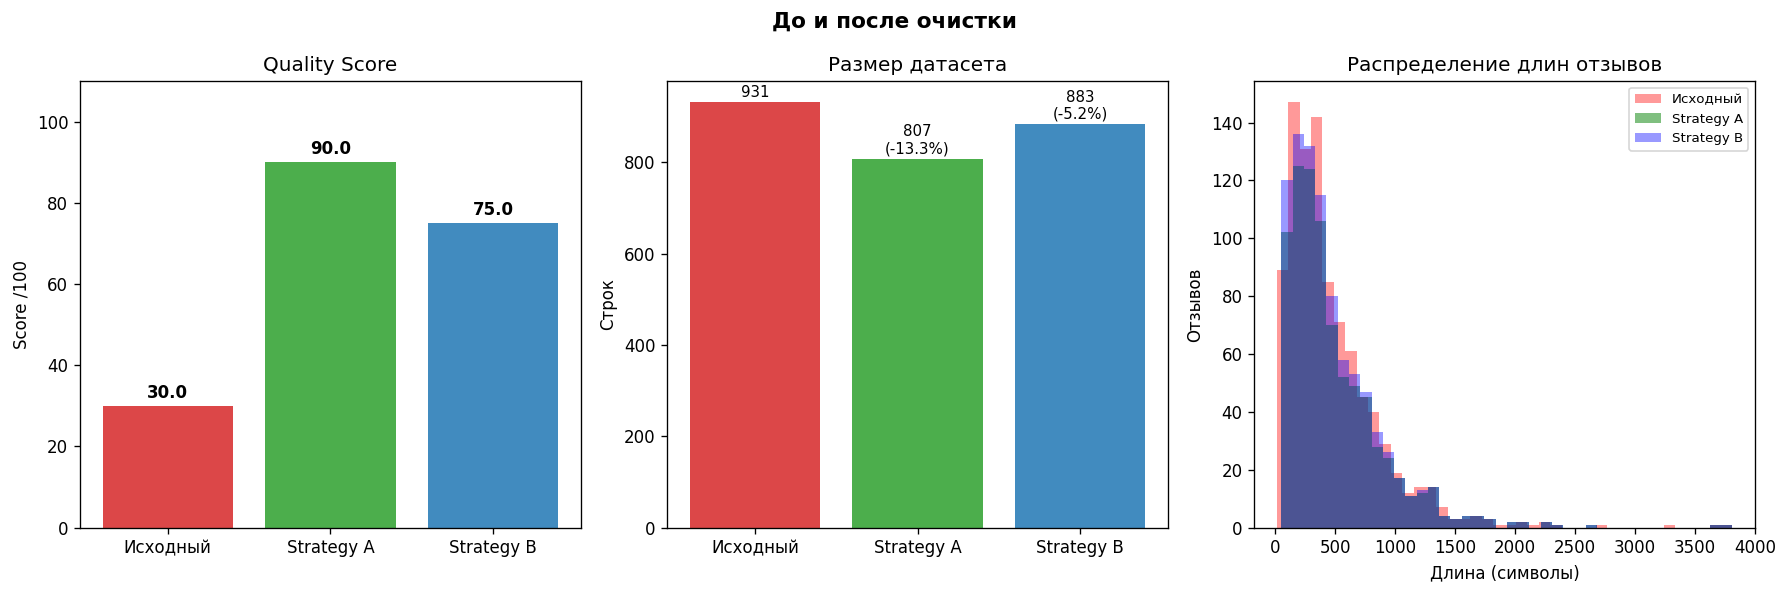

График сохранён: data/reports/fig_strategy_comparison.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('До и после очистки', fontsize=13, fontweight='bold')

# Quality Scores
ax = axes[0]
scores = [report_phase1['quality_score'], report_a['quality_score'], report_b['quality_score']]
labels = ['Исходный', 'Strategy A', 'Strategy B']
colors = ['#d62728', '#2ca02c', '#1f77b4']
bars = ax.bar(labels, scores, color=colors, alpha=0.85)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{score}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 110)
ax.set_title('Quality Score')
ax.set_ylabel('Score /100')

# Размеры датасетов
ax = axes[1]
sizes = [len(df), len(df_a), len(df_b)]
bars = ax.bar(labels, sizes, color=colors, alpha=0.85)
for bar, sz in zip(bars, sizes):
    loss = (1 - sz/len(df)) * 100
    label = f'{sz}' if sz == len(df) else f'{sz}\n(-{loss:.1f}%)'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            label, ha='center', va='bottom', fontsize=9)
ax.set_title('Размер датасета')
ax.set_ylabel('Строк')

# Распределение длин отзывов
ax = axes[2]
ax.hist(df['review_text'].str.len(), bins=40, alpha=0.4, label='Исходный', color='red')
ax.hist(df_a['review_text'].str.len(), bins=40, alpha=0.5, label='Strategy A', color='green')
ax.hist(df_b['review_text'].str.len(), bins=40, alpha=0.4, label='Strategy B', color='blue')
ax.set_title('Распределение длин отзывов')
ax.set_xlabel('Длина (символы)')
ax.set_ylabel('Отзывов')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/reports/fig_strategy_comparison.png', bbox_inches='tight')
plt.show()
print('График сохранён: data/reports/fig_strategy_comparison.png')

## 7. Сохранение fix-отчёта

In [8]:
fix_report = {
    'original_shape': list(df.shape),
    'decisions': [
        {'issue': 'encoding_corruption', 'action': 'drop', 'rows_dropped': int(enc_mask.sum())},
        {'issue': 'short_review', 'action': 'drop', 'rows_dropped': int((short_mask & ~enc_mask).sum())},
    ],
    'strategy_a': {
        'name': 'conservative',
        'description': 'Drop encoding/short + deduplicate reviewers (keep longest review)',
        'rows': len(df_a),
        'loss_pct': round((1 - len(df_a)/len(df)) * 100, 2),
        'quality_score': report_a['quality_score'],
        'file': 'data/cleaned/strategy_a.csv',
    },
    'strategy_b': {
        'name': 'soft',
        'description': 'Drop encoding/short + flag duplicate reviewers',
        'rows': len(df_b),
        'loss_pct': round((1 - len(df_b)/len(df)) * 100, 2),
        'quality_score': report_b['quality_score'],
        'file': 'data/cleaned/strategy_b.csv',
    },
}

path = save_report(fix_report, '../data/reports/fix_report.json')
print(f'Fix-отчёт сохранён: {path}')
print()
print('=== ИТОГ ===')
print(f'Strategy A: {len(df)} → {len(df_a)} строк  (потеря {fix_report["strategy_a"]["loss_pct"]}%),  QS={report_a["quality_score"]}/100')
print(f'Strategy B: {len(df)} → {len(df_b)} строк  (потеря {fix_report["strategy_b"]["loss_pct"]}%),  QS={report_b["quality_score"]}/100')

Fix-отчёт сохранён: ..\data\reports\fix_report.json

=== ИТОГ ===
Strategy A: 931 → 807 строк  (потеря 13.32%),  QS=90.0/100
Strategy B: 931 → 883 строк  (потеря 5.16%),  QS=75.0/100
